# Complete Lecture 1 Summary: Machine Learning & Data Preprocessing

## Part 1: Core Concepts & Model Training Mechanics

* **Evaluating Model Performance:** Never report raw predicted labels. Use evaluation metrics like loss value, Mean Squared Error (MSE), or accuracy.
* **Calculating Loss Manually:**
* **True Label ($y$) vs. Predicted Label ($y'$):** The error for a single row is $y_i - y'_i$.
* **Average Loss:** The average of these differences across all $N$ rows.


* **Linear Regression Mechanics ($Y = MX + B$):**
* **$M$ (Slope):** The proportional relationship between input ($X$) and target ($Y$).
* **$B$ (Y-intercept):** The starting point when $X$ is zero. The model iteratively adjusts $M$ and $B$ to minimize loss.


* **Train vs. Test Split:**
* **Training Set (70–80%):** Used by the model to learn patterns and update parameters.
* **Test Set (20–30%):** Unseen data kept completely separate to evaluate final model performance. A large gap between training and test performance indicates **overfitting**.



---

## Part 2: Practical Coding & Data Loading (Python/Pandas)

* **IDE:** The tutor used **PyCharm** for step-by-step debugging (setting breakpoints, inspecting variables with `F8`, and viewing dataframes interactively).
* **Loading & Inspecting Data:**
```python
import pandas as pd
data = pd.read_csv("housing.csv")
print(data.shape)  # e.g., 20,640 rows by 10 columns

```


* **Handling Missing Data:** Cleaned missing values using `.dropna()` before training.
* **Identifying Features vs. Target:**
* **Target:** `median_house_value` (continuous numeric value to predict).
* **Features:** Attributes like housing median age, total rooms, population, and `ocean_proximity`.



---

## Part 3: Feature Selection & Dropping Useless Columns

* **Feature Relevance:** Drop columns that carry no predictive value for the target (e.g., row ID columns like `ID1`, `ID2`). Keep only features strongly correlated with the target.

---

## Part 4: Handling Categorical Data via One-Hot Encoding

* **The Problem:** Machine learning models require numerical inputs, but features like `ocean_proximity` contain text categories (e.g., *near*, *inland*, *island*).
* **Why One-Hot Encoding?**
* Assigning sequential numbers ($1, 2, 3$) to categories can falsely imply a mathematical order or distance between them.
* **One-hot encoding** solves this by creating a separate binary column for each unique category, assigning `1` (on) to the matching category and `0` (off) to all others.


* **Pandas Implementation:**
```python
# Generate dummy/binary columns for the categorical feature
dummy_cols = pd.get_dummies(data["ocean_proximity"])

```



---

## Part 5: Updating and Finalizing the Dataset

1. **Drop the original text column:**
```python
data = data.drop("ocean_proximity", axis=1)

```


2. **Concatenate the new dummy columns** back into the main dataset (bringing the total feature count up, e.g., from 9 numeric columns plus 5 new binary columns = 14 columns).
3. **Takeaway:** Data preprocessing and cleaning is typically the most time-consuming part of data science. Once the dataset is fully cleaned and numerical, fitting a model takes just a couple of lines of code.

---

## Part 6: Logistics & Next Steps

* **Assignment Update:** The Moodle assignment deadline has been postponed by one week (moved from the 9th to the 16th) to give students extra time to practice the preprocessing workflow.
* **Next Week:** We will finish the remaining steps and build/train the linear regression model.

## Data Preprocessing Part

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('housing.csv')

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
data = data.dropna()

In [4]:
data["ocean_proximity"].value_counts()
# As we can see that the ocean proximity column is a categorical variable, we will need to convert it into numerical values using one-hot encoding.
# I guess the value count of island is very low, so we can drop that column as it will not have much impact on the model.

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [5]:
# Lets change the ocean proximity column into numerical values using one-hot encoding.
categorical_columns = ['ocean_proximity']
data = pd.get_dummies(data, columns=categorical_columns, dtype=int)

In [6]:
data.head()
data = data.drop('ocean_proximity_ISLAND', axis=1) # Dropping the island column as it has very low value counts and will not have much impact on the model.

## Define Target and Features

In [7]:
y = data['median_house_value'] # This is our target variable that we need to predict.
features = data.drop('median_house_value', axis=1) # These are the features that we will use to predict the target variable.

## Model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

In [11]:
# Make instance of the model
reg = LinearRegression()

# Train the model
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ -27108.75, -25657.81, 1081.36,...,-252893.59,-219885.79,-210486.9 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['longitude','latitude','housing_median_age',...,'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.086e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [12]:
# We can now use the trained model to make predictions on the test set and evaluate its performance. Let's do that next.
y_pred = reg.predict(X_test)
print("Predictions: ", y_pred[:5])  # Print first 5 predictions

Predictions:  [201882.95986765 147279.68214385 207796.60979847 180487.57672192
 190323.92313024]


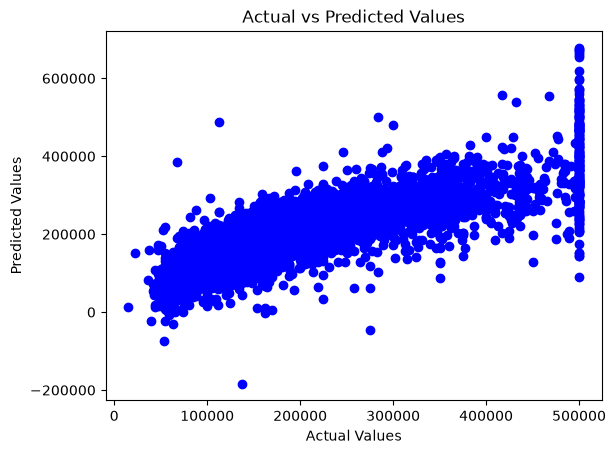

In [13]:
# Visualize the predictions against the actual values
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [14]:
# Print the mean squared error and R-squared value to evaluate the model's performance
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error: ", mse)
print("R-squared: ", r2)

Mean Squared Error:  4802173538.604144
R-squared:  0.6488402154432005
